# Pizza Place Sales — Exploratory Data Analysis

**Files:** `orders.csv`, `order_details.csv`, `pizzas.xlsx`, `pizza_types.xlsx`

**A note on ordering:** the raw files turned out to have real data quality problems
(mixed date formats, `$` signs mixed into a numeric price column, inconsistent
category/size spellings, duplicate keys, orphaned foreign keys). Merging first and
cleaning after would let duplicate keys silently multiply rows during the join, and
would push text/type problems into every downstream step. So the order here is:

**Setup → Load → Profile each raw file → Clean each raw file → Merge → Inspect final
data → Univariate → Bivariate/Multivariate → Time-based → Visualization → Insights**

## 1. Import libraries

In [17]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from matplotlib.ticker import FuncFormatter

# just so plots look a bit nicer by default
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 2. Check Files

In [18]:
import os
files = [f for f in os.listdir('.') if f.endswith(('.csv', '.xlsx'))]
print(f"Data files found: {files}")

Data files found: []


## 3. Load the files

In [19]:
orders        = pd.read_csv('data/orders.csv')
order_details = pd.read_csv('data/order_details.csv')
pizzas        = pd.read_excel('data/pizzas.xlsx')
pizza_types   = pd.read_excel('data/pizza_types.xlsx')

print("orders:        ", orders.shape)
print("order_details: ", order_details.shape)
print("pizzas:        ", pizzas.shape)
print("pizza_types:   ", pizza_types.shape)

orders:         (85656, 3)
order_details:  (194966, 4)
pizzas:         (394, 4)
pizza_types:    (136, 4)


## 4. Take a first look at each file

In [20]:
print("--- orders ---")
display(orders.head(4))

print("--- order_details ---")
display(order_details.head(4))

print("--- pizzas ---")
display(pizzas.head(4))

print("--- pizza_types ---")
display(pizza_types.head(4))

--- orders ---


,order_id,date,time
0,53143.0,2023-10-19,19:22:31
1,19912.0,2023-04-21,21:54:57
2,82571.0,2023-05-27,17:57:24
3,38004.0,2023-06-14,13:03:02


--- order_details ---


,order_detail_id,order_id,pizza_id,quantity
0,23179,27236,pz_0377,1.0
1,75465,51059,pz_0153,2.0
2,170029,81554,pz_0083,3.0
3,46582,20574,pz_0206,3.0


--- pizzas ---


,pizza_id,pizza_type_id,size,price
0,pz_0290,pt_050,XL,21.59
1,pz_0281,pt_056,M,$14.41
2,pz_0106,pt_093,s,$8.13
3,pz_0003,pt_075,XL,20.05


--- pizza_types ---


,pizza_type_id,name,category,ingredients
0,pt_006,The Hawaiian Classic,Classic,"Arugula, Green Peppers, Garlic, Kalamata Olive..."
1,pt_109,The Prosciutto Classic,Supreme,"Anchovies, Truffle Oil, Kalamata Olives, Gouda..."
2,pt_100,The Bacon Classic,Veggie,"Chipotle Sauce, Green Peppers, Smoked Salmon"
3,pt_066,The Mediterranean Feast,Veggie,"Barbecue Sauce, Prosciutto, Thyme"


## 5. Check for problems before we merge

Just doing `.isnull().sum()` and `.duplicated().sum()` on each file to see
what we're dealing with.

In [21]:
def profile(df, name):
    print(f"\n=== {name} ===  shape={df.shape}")
    print("\nmissing values:\n", df.isnull().sum())
    print("full duplicate rows:", df.duplicated().sum())

profile(orders, "orders")
profile(order_details, "order_details")
profile(pizzas, "pizzas")
profile(pizza_types, "pizza_types")


=== orders ===  shape=(85656, 3)

missing values:
 order_id       0
date        1286
time        1712
dtype: int64
full duplicate rows: 256

=== order_details ===  shape=(194966, 4)

missing values:
 order_detail_id       0
order_id              0
pizza_id           1562
quantity           2340
dtype: int64
full duplicate rows: 486

=== pizzas ===  shape=(394, 4)

missing values:
 pizza_id          0
pizza_type_id     0
size              0
price            12
dtype: int64
full duplicate rows: 6

=== pizza_types ===  shape=(136, 4)

missing values:
 pizza_type_id    0
name             3
category         0
ingredients      7
dtype: int64
full duplicate rows: 4


So basically:
- `orders` has some missing dates/times, and some duplicate rows
- `order_details` has missing pizza_id/quantity, some negative quantities, and duplicate rows
- `pizzas` price column is messy (some values have a `$` in front), and size has typos like `Xl`, `s`, `' M'`
- `pizza_types` category has typos too, like `Suprem`, `veggei`, `CHICKEN`

Let's clean each one up.

## 6. Clean the data

In [22]:
# --- orders ---
orders = orders.drop_duplicates()

# just let pandas try to figure out the dates automatically
orders['date'] = pd.to_datetime(orders['date'], errors='coerce') # (any invalid date becomes NaT, which we then drop)
orders = orders.dropna(subset=['date'])
orders = orders[(orders['date'].dt.year >= 2023) & (orders['date'].dt.year <= 2023)]

# clean up the time column too, so we can look at what hour most orders happen
orders['time'] = pd.to_datetime(orders['time'], format='%H:%M:%S', errors='coerce').dt.time

orders.isnull().sum()


order_id       0
date           0
time        1576
dtype: int64

In [23]:
# --- order_details ---
order_details = order_details.drop_duplicates()

# can't calculate revenue without knowing which pizza or how many were ordered
order_details = order_details.dropna(subset=['pizza_id', 'quantity'])

# negative or 0 quantity doesn't make sense, so drop those rows
order_details = order_details[order_details['quantity'] >= 0]

order_details.isnull().sum()


order_detail_id    0
order_id           0
pizza_id           0
quantity           0
dtype: int64

In [24]:
# --- pizzas ---
pizzas = pizzas.drop_duplicates(subset='pizza_id')

# remove the '$' sign so the whole column can become a number
pizzas['price'] = pizzas['price'].astype(str).str.replace('$', '', regex=False)

# we choose to drop missing price rows
pizzas = pizzas.dropna(subset=['price'])

# this turns 'Xl', 's', ' M' etc. into clean 'XL', 'S', 'M'
pizzas['size'] = pizzas['size'].str.strip().str.upper()

print(pizzas['size'].unique())
pizzas.isnull().sum()


['XL' 'M' 'S' 'L' 'XXL']


pizza_id         0
pizza_type_id    0
size             0
price            0
dtype: int64

In [25]:
# --- pizza_types ---
pizza_types = pizza_types.drop_duplicates(subset='pizza_type_id')

# fix the typos in category by mapping them to the correct spelling
fix_typos = {
    'suprem': 'supreme',
    'veggei': 'veggie',
    'clasic': 'classic',
    'chickken': 'chicken'}
pizza_types['category'] = pizza_types['category'].str.strip().str.lower().replace(fix_typos).str.title()

# dropping the few rows missing a name.
pizza_types = pizza_types.dropna(subset=['name'])

# ingredients isn't used in any grouping, so a placeholder here is fine
pizza_types['ingredients'] = pizza_types['ingredients'].fillna('Not specified')

print(pizza_types['category'].unique())
pizza_types.isnull().sum()


['Classic' 'Supreme' 'Veggie' 'Chicken']


pizza_type_id    0
name             0
category         0
ingredients      0
dtype: int64

## 7. Merge everything into one table

In [26]:
df = orders.merge(order_details, on='order_id', how='inner')
df = df.merge(pizzas, on='pizza_id', how='inner')
df = df.merge(pizza_types, on='pizza_type_id', how='inner')

# a little extra column that we'll use a lot: firstly we have to change its dtype
df['price'] = df['price'].astype(float)
df['quantity'] = df['quantity'].astype(int)
df['revenue'] = df['quantity'] * df['price']

# fixing other dtypes
df['order_id'] = df['order_id'].astype(int)

print(df.shape)
df.head()

(168377, 13)


,order_id,date,time,order_detail_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients,revenue
0,53143,2023-10-19,19:22:31,143789,pz_0262,1,pt_025,L,14.97,The Pesto Classic,Chicken,"Chicken, Duck, Basil, Arugula, Jalapeno Pepper...",14.97
1,53143,2023-10-19,19:22:31,42199,pz_0348,2,pt_036,S,9.52,The Soppressata Delight,Chicken,"Kalamata Olives, Artichokes, Truffle Oil, Sun-...",19.04
2,19912,2023-04-21,21:54:57,30393,pz_0278,1,pt_035,L,14.88,The Fiery Supreme,Veggie,"Duck, Caramelized Onions, Cilantro, Buffalo Mo...",14.88
3,19912,2023-04-21,21:54:57,190035,pz_0292,2,pt_022,XXL,25.61,The Buffalo Feast,Supreme,"Cilantro, Bacon, Gouda Cheese, Parmesan Cheese...",51.22
4,38004,2023-06-14,13:03:02,17788,pz_0070,2,pt_046,XL,20.94,The Green Garden Feast,Chicken,"Corn, Kalamata Olives, Mushrooms, Capers, Toma...",41.88


In [28]:
# check again
df.isnull().sum()

order_id              0
date                  0
time               3524
order_detail_id       0
pizza_id              0
quantity              0
pizza_type_id         0
size                  0
price              5390
name                  0
category              0
ingredients           0
revenue            5390
dtype: int64

## 8. Basic overview of the clean data

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168377 entries, 0 to 168376
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   order_id         168377 non-null  int32         
 1   date             168377 non-null  datetime64[ns]
 2   time             164853 non-null  object        
 3   order_detail_id  168377 non-null  int64         
 4   pizza_id         168377 non-null  object        
 5   quantity         168377 non-null  int32         
 6   pizza_type_id    168377 non-null  object        
 7   size             168377 non-null  object        
 8   price            162987 non-null  float64       
 9   name             168377 non-null  object        
 10  category         168377 non-null  object        
 11  ingredients      168377 non-null  object        
 12  revenue          162987 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int32(2), int64(1), object(7)
memory usa

In [30]:
df.describe()

,order_id,date,order_detail_id,quantity,price,revenue
count,168377.000000,168377,168377.000000,168377.000000,162987.000000,162987.000000
mean,42612.825035,2023-07-02 04:23:42.493571072,97225.725788,1.652346,18.570555,30.597488
min,1.000000,2023-01-01 00:00:00,1.000000,0.000000,-5.500000,-22.000000
25%,21248.000000,2023-04-02 00:00:00,48524.000000,1.000000,11.850000,14.670000
50%,42605.000000,2023-07-03 00:00:00,97339.000000,1.000000,15.040000,22.190000
75%,63930.000000,2023-10-01 00:00:00,145839.000000,2.000000,21.190000,34.640000
max,85400.000000,2023-12-31 00:00:00,194480.000000,100.000000,300.000000,6599.670000
std,24600.086593,NaN,56169.081966,1.039357,22.847064,47.910300


In [31]:
df.describe(include = 'object')

,time,pizza_id,pizza_type_id,size,name,category,ingredients
count,164853,168377,168377,168377,168377,168377,168377
unique,31920,375,129,5,129,4,124
top,21:00:14,pz_0334,pt_074,S,The Napolitana Feast,Veggie,Not specified
freq,29,497,2310,36453,2310,49907,9422


## 9. Univariate analysis

In [32]:
# Quantity vs its count
df['quantity'].value_counts().sort_index()

quantity
0          4
1      92844
2      50471
3      16713
4       8325
25         4
33         4
40         4
50         4
100        4
Name: count, dtype: int64

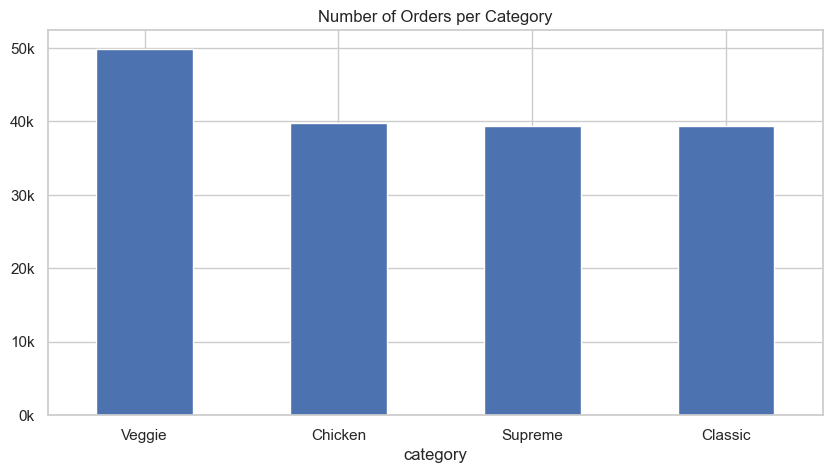

In [36]:
# Number of Orders per Category
ax = df['category'].value_counts().plot(kind='bar')
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1000:.0f}k'))
plt.title('Number of Orders per Category')
sns.set(rc = {'figure.figsize':(10,2)})
plt.xticks(rotation=0)
plt.show()

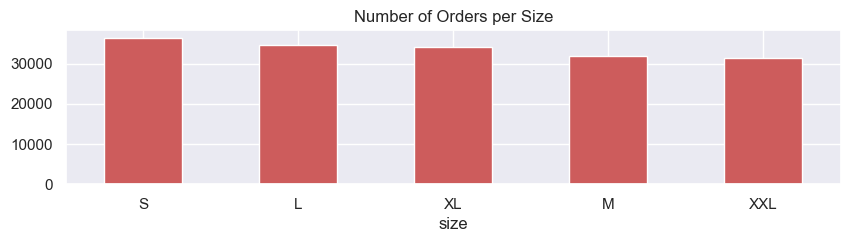

In [37]:
# Number of Orders per pizza size 
df['size'].value_counts().plot(kind='bar', color='indianred')
plt.title('Number of Orders per Size')
plt.xticks(rotation=0)
plt.show()

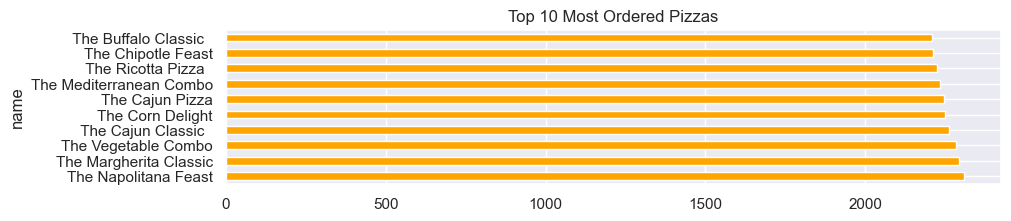

In [41]:
# Top 10 Most Ordered Pizzas
df['name'].value_counts().head(10).plot(kind='barh', color='orange')
plt.title('Top 10 Most Ordered Pizzas')
sns.set(rc = {'figure.figsize':(15,5)})
plt.show()

## 10. Bivariate analysis

In [42]:
# average price per category
df.groupby('category')['price'].mean().sort_values(ascending=False)

category
Supreme    22.266994
Classic    18.575092
Chicken    17.273301
Veggie     16.623637
Name: price, dtype: float64

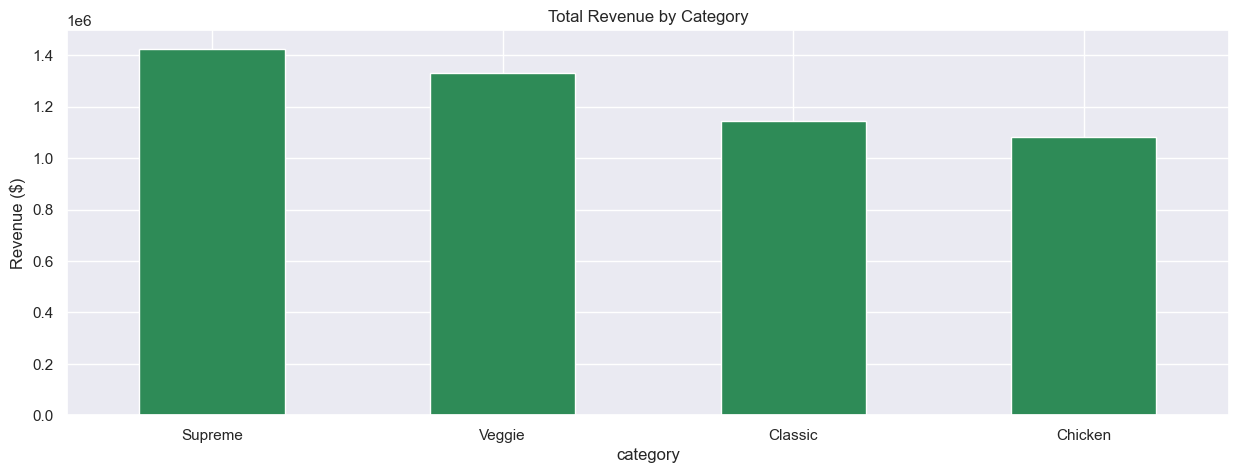

In [44]:
# total revenue per category
df.groupby('category')['revenue'].sum().sort_values(ascending=False).plot(kind='bar', color='seagreen')
plt.title('Total Revenue by Category')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=0)
plt.show()

## 11. Time-based analysis

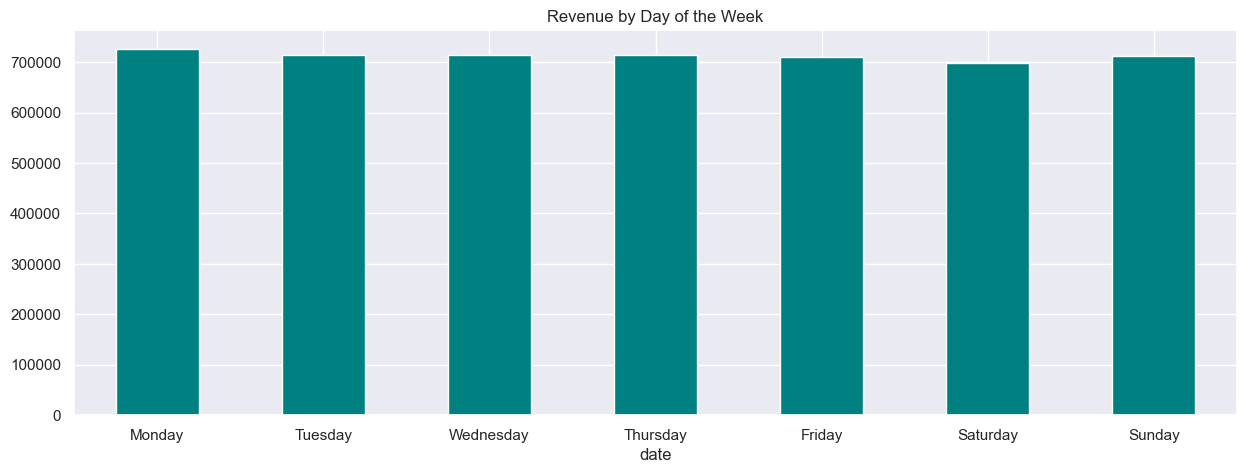

In [46]:
# which day of the week makes the most money?
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df.groupby(df['date'].dt.day_name())['revenue'].sum().reindex(day_order).plot(kind='bar', color='teal')
plt.title('Revenue by Day of the Week')
plt.xticks(rotation=0)
plt.show()

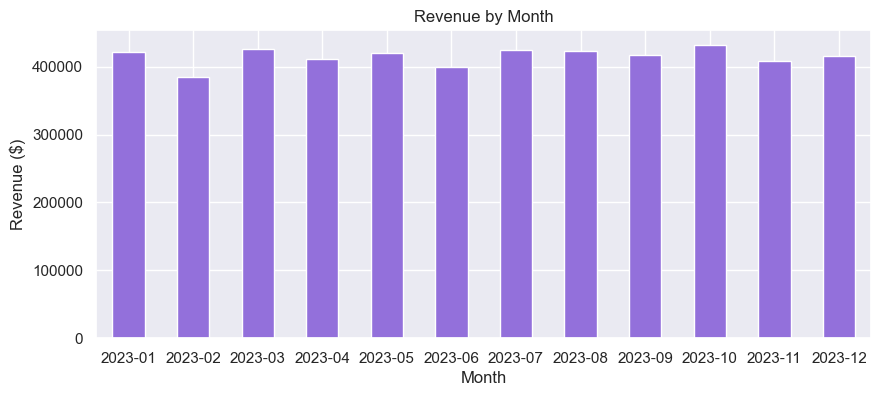

In [48]:
# revenue per month
monthly_revenue = df.groupby(df['date'].dt.to_period('M'))['revenue'].sum()

monthly_revenue.plot(kind='bar', color='mediumpurple', figsize=(10,4))
plt.title('Revenue by Month')
plt.ylabel('Revenue ($)')
plt.xlabel('Month')
plt.xticks(rotation=0)
plt.show()

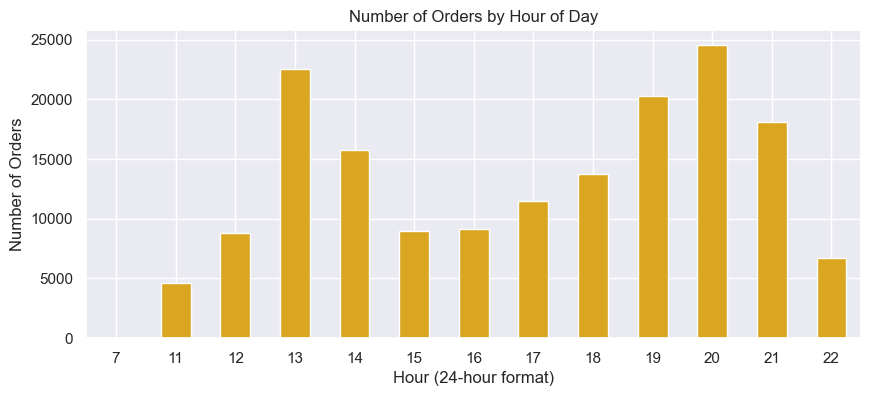

In [50]:
# what hour of the day do most orders happen?
hour_counts = df['time'].dropna().apply(lambda t: t.hour).value_counts().sort_index()

hour_counts.plot(kind='bar', color='goldenrod', figsize=(10,4))
plt.title('Number of Orders by Hour of Day')
plt.xlabel('Hour (24-hour format)')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.show()

## 12. Insights

In [51]:
print("Total revenue:", round(df['revenue'].sum(), 2))
print("Total orders:", df['order_id'].nunique())
print("Average order value:", round(df['revenue'].sum() / df['order_id'].nunique(), 2))
print("Best-selling category:", df.groupby('category')['revenue'].sum().idxmax())
print("Best-selling pizza:", df['name'].value_counts().idxmax())

Total revenue: 4986992.81
Total orders: 69174
Average order value: 72.09
Best-selling category: Supreme
Best-selling pizza: The Napolitana Feast


**What we found:**
- These numbers above are the main things you'd tell someone if they asked "how's the pizza business doing"
- The category chart in section 9 shows which category actually brings in the most money, not just which one gets ordered the most
- The revenue-over-time chart shows if sales are growing, flat, or seasonal
- The day-of-week chart is useful for something practical, like deciding which days need more staff